# Titanic_practice

## loading library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# i'll import other libraries along the way

## Loading the data

In [2]:
train_df=pd.read_csv('/kaggle/input/titanic/train.csv')
test_df=pd.read_csv('/kaggle/input/titanic/test.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Basic EDA

In [5]:
# to know shape of the our data
train_df.shape,test_df.shape

((891, 12), (418, 11))

In [6]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
# basic knowledge about data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# to get statistical info about the data
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train_df.nunique() # to knoq unique number of features in each feature

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
# Droping name column cause theres no need of that
train_df.drop(columns=['Name'],inplace=True)
test_df.drop(columns=['Name'],inplace=True)

In [11]:
# to check for null values
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are some null values in the dataset 

## Handling missing values

In [12]:
# for age feature since it has less null values we can replace them with median of the values in it
train_df['Age'].fillna(train_df['Age'].mean(),inplace=True)

/tmp/ipykernel_17/439986756.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].mean(),inplace=True)


In [13]:
# since cabin has so many null values in it we will create new feature callled hascabin 
train_df['HasCabin']=train_df['Cabin'].notnull().astype('int64')

In [14]:
train_df['HasCabin']

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: HasCabin, Length: 891, dtype: int64

In [15]:
train_df['SibSp'] # siblings / spouses aboard the Titanic

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: SibSp, Length: 891, dtype: int64

In [16]:
train_df['Parch'] # parents / children aboard the Titanic	

0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    2
889    0
890    0
Name: Parch, Length: 891, dtype: int64

In [17]:
# here sibsp and parch is a family size so we will convert them to one feature called family size
train_df['Family Size']=train_df['SibSp']+train_df['Parch']+1 # adding 1 to count the main man of the family

In [18]:
train_df['Family Size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family Size, Length: 891, dtype: int64

In [19]:
# dropping all the unnecessory columns or features that have null values
train_df.drop(columns=['Cabin','SibSp','Parch'],inplace=True)

In [20]:
# checking for null values again
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Ticket         0
Fare           0
Embarked       2
HasCabin       0
Family Size    0
dtype: int64

Problem solved!

In [21]:
# For duplicated values
train_df.duplicated().sum(),test_df.duplicated().sum()

(np.int64(0), np.int64(0))

which means there are no duplicaetd values in our dataset

## Visual EDA

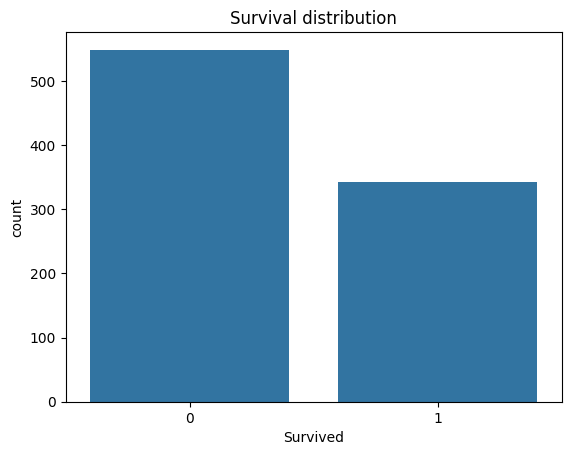

In [22]:
# survived
sns.countplot(data=train_df,x='Survived')
plt.xlabel('Survived')
plt.title('Survival distribution')
plt.show()

The above graph shows us that survival distribution where we can see there were more people dead in compare to the survived people


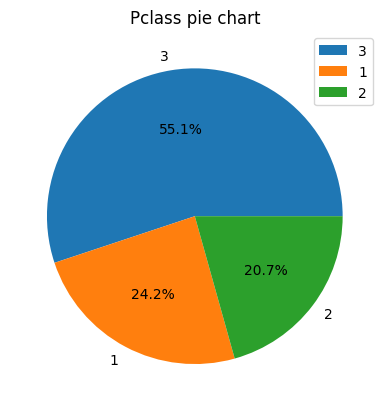

In [23]:
# pclass
l=train_df['Pclass'].value_counts()
plt.pie(l.values,labels=l.index,autopct="%1.1f%%")
plt.title('Pclass pie chart')
plt.legend()
plt.show()

The above pie charts shows us that people class was mostly 3 

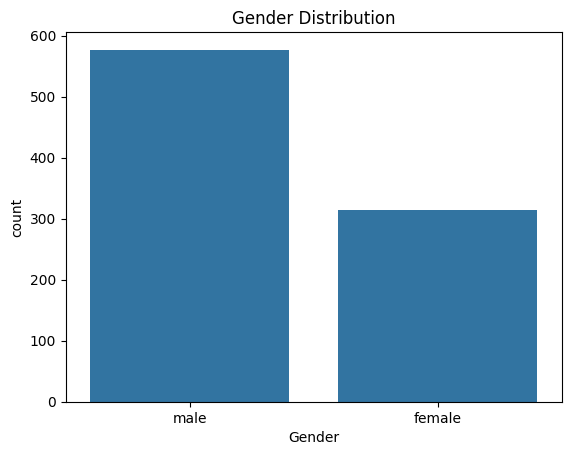

In [24]:
# gender
sns.countplot(data=train_df,x='Sex')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.show()

above graph shows us gender distribution in our data where we can say there were more male on the boat than feamle

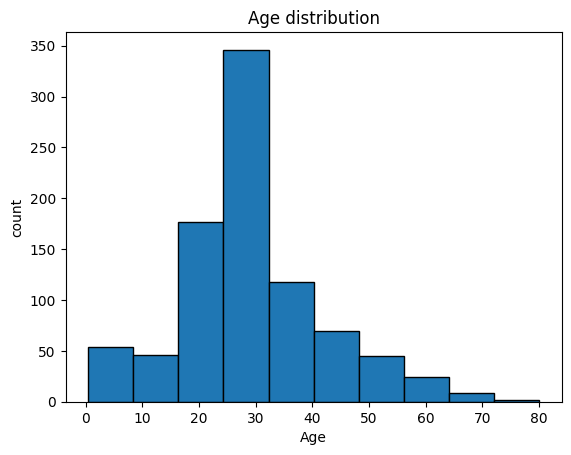

In [25]:
plt.hist(data=train_df,x='Age',edgecolor='black')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('count')
plt.show()

The above histogram shows us age distribution in our data where we can say most of the people age is between 25 to 33

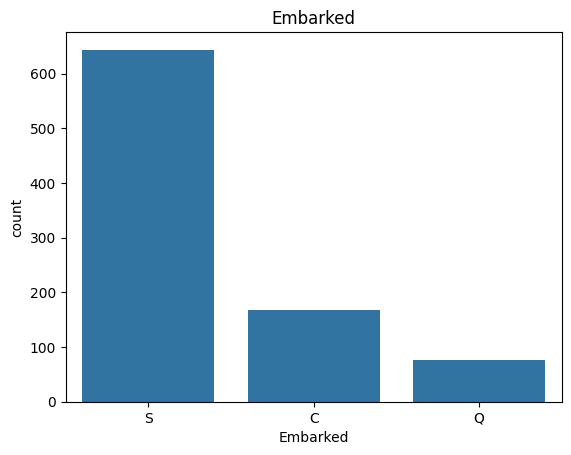

In [26]:
sns.countplot(data=train_df,x='Embarked')
plt.title("Embarked")
plt.xlabel('Embarked')
plt.show()

above graph shows us distribution of the emarked feature in our data

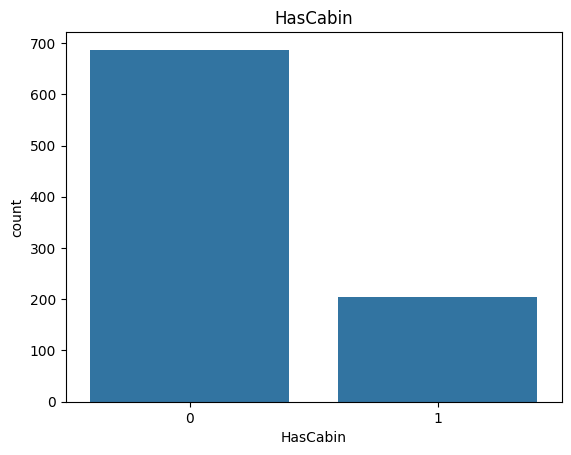

In [27]:
sns.countplot(data=train_df,x='HasCabin')
plt.title("HasCabin")
plt.xlabel('HasCabin')
plt.show()

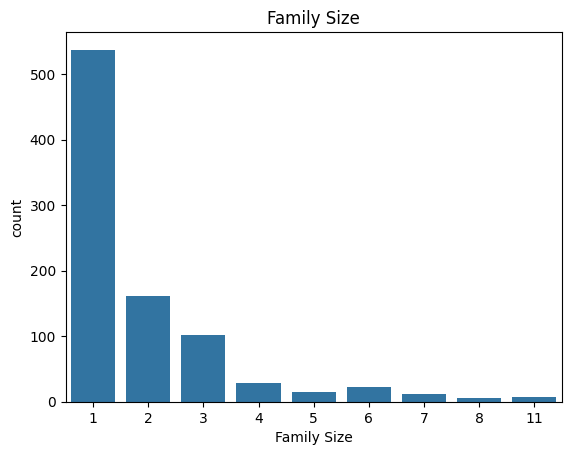

In [28]:
sns.countplot(data=train_df,x='Family Size')
plt.title("Family Size")
plt.xlabel('Family Size')
plt.show()

The above graph shows us that most of the person came alone

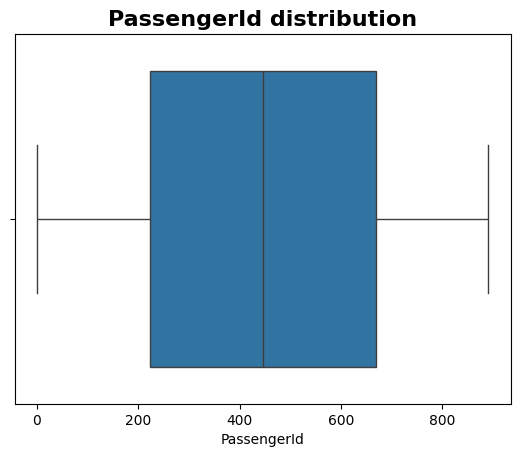

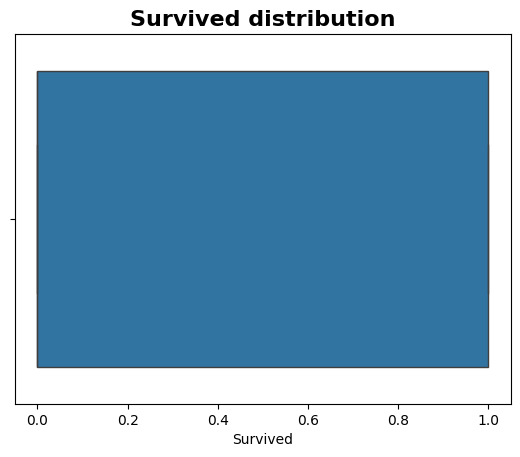

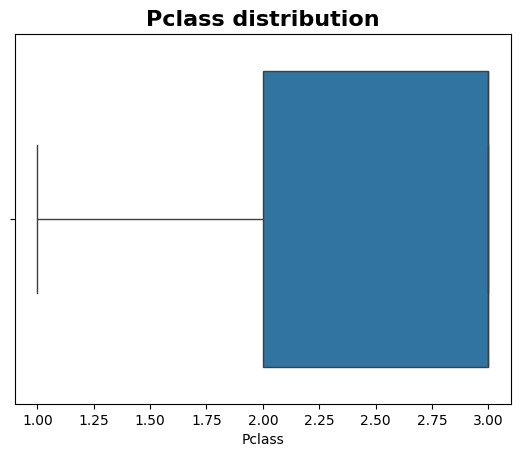

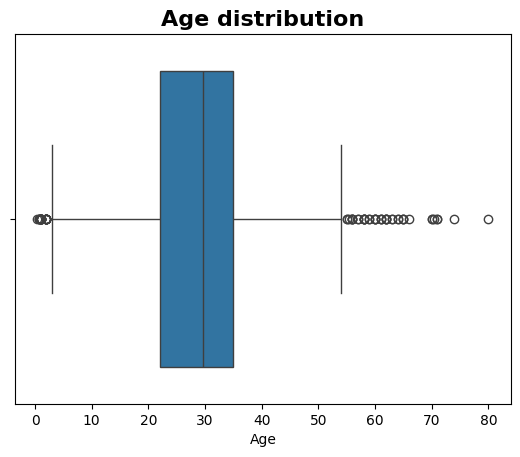

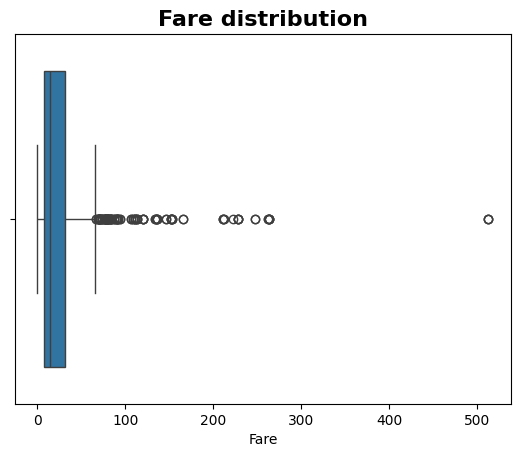

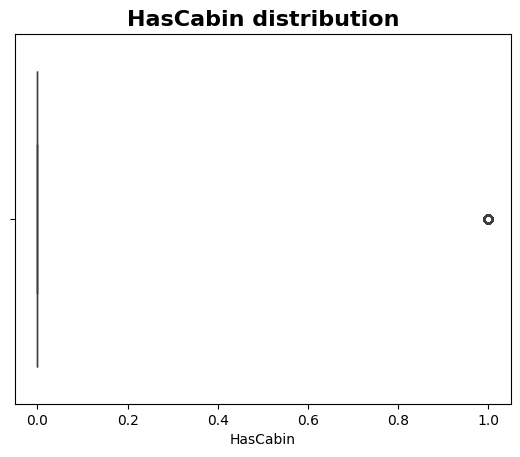

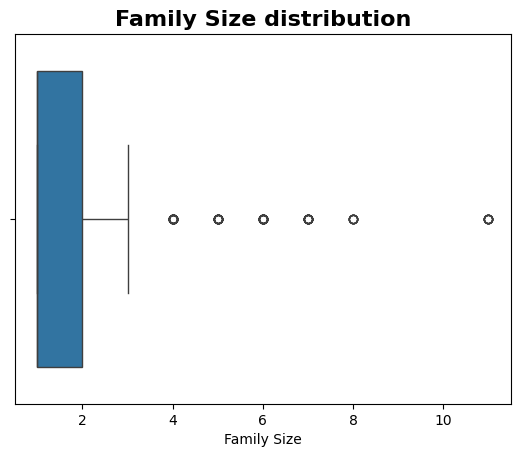

In [29]:
num_df=train_df.select_dtypes(include=['int64','float64'])
for i in num_df:    
    sns.boxplot(x=i,data=train_df)
    plt.title(f"{i} distribution",fontsize=16,fontweight="bold")
    plt.show()

The boxplot shows us number of outliers in our data since they are less we dont need to remove them

## Data Preprocessing

In [30]:
# toconvert categorical values into numerical for model building
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [31]:
cat_df=train_df.select_dtypes(include=['object'])
for i in cat_df:
    train_df[i]=le.fit_transform(train_df[i])
train_df

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,HasCabin,Family Size
0,1,0,3,1,22.000000,523,7.2500,2,0,2
1,2,1,1,0,38.000000,596,71.2833,0,1,2
2,3,1,3,0,26.000000,669,7.9250,2,0,1
3,4,1,1,0,35.000000,49,53.1000,2,1,2
4,5,0,3,1,35.000000,472,8.0500,2,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.000000,101,13.0000,2,0,1
887,888,1,1,0,19.000000,14,30.0000,2,1,1
888,889,0,3,0,29.699118,675,23.4500,2,0,4
889,890,1,1,1,26.000000,8,30.0000,0,1,1


## Spliting our data train-test

In [32]:
X=train_df.drop(columns=["Survived"])
Y=train_df['Survived']

In [33]:
y = train_df["Survived"]
test_ids = test_df["PassengerId"]

X = train_df.drop(columns=["Survived"])
X_test = test_df.drop(columns=["PassengerId"])

**We separate features (X) and labels (y), remove ID columns from training data, and keep IDs only for submission.**

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(X,y, test_size=0.2, random_state=42)

### Scaling our data
we can see here our features are not in simillar range which can effect our model so we have to scale our features

In [35]:
from sklearn.preprocessing import StandardScaler
s=StandardScaler()

In [36]:
cols=['Age','Fare','Family Size']
x_val[cols]=s.fit_transform(x_val[cols])
x_train[cols]=s.fit_transform(x_train[cols])

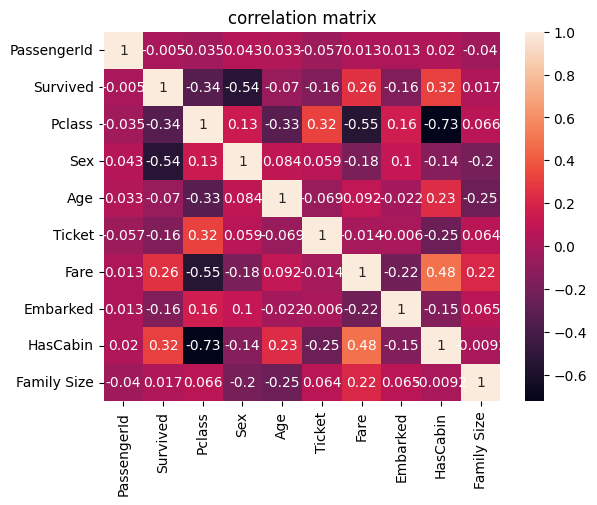

In [37]:
sns.heatmap(train_df.corr(),annot=True)
plt.title('correlation matrix')
plt.show()

The correlation matrix shows all the relationship exist among different features of out data

## Modeling

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()

In [39]:
rf_model=rf.fit(x_train,y_train)

In [40]:
y_pred=rf.predict(x_val)

In [41]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

## model performance

In [42]:
from sklearn.metrics import accuracy_score, classification_report
rf_acc=accuracy_score(y_pred,y_val)
rf_report=classification_report(y_val,y_pred)

In [43]:
rf_acc

0.8547486033519553

In [44]:
print(rf_report)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       105
           1       0.85      0.78      0.82        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.85       179
weighted avg       0.85      0.85      0.85       179



In [45]:
submission = pd.DataFrame({
    "PassengerId": x_val["PassengerId"],
    "Survived": y_pred
})
submission.to_csv("submission.csv", index=False)

## Cross validation

In [46]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(rf_model,X,y,cv=10)
cvs

array([0.77777778, 0.83146067, 0.76404494, 0.82022472, 0.87640449,
       0.85393258, 0.86516854, 0.83146067, 0.87640449, 0.84269663])

In [47]:
cvs.mean()

np.float64(0.8339575530586766)

### Cross-Validation conclusion
Cross validation was done with 10-fold CV. The model showed consistently high accuracy across all folds, confirming that it generalizes well and is not overfitting to a single train–test split.

# Thank you
for reading till the end

if you have any suggestion dont forget to comment

if you like the notebook dont forget to upvote, it means alot :)